<a href="https://colab.research.google.com/github/EthanJF-Physics/MAT422/blob/main/MAT422HW2EthanF.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

All of the definitions, theorems, and lemmas used in this homework are drawn from the first edition of Mathematical Methods in Data Science (January 6, 2023), published by Elsevier and authored by Jingli Ren and Haiyan Wang.

In [ ]:
#MAT422 HW1.3
import matplotlib.pyplot as plt
import numpy as np
# Set the matrix size
matrix_size = 3
# Function to generate a random square matrix
def random_matrix(size: int = 3):
    return np.random.randint(0, 10, [size, size])
# Generate random matrices
A = random_matrix(matrix_size)
B = random_matrix(matrix_size)
print("Random 3x3 matrix A:")
print(A)
print("\nRandom 3x3 matrix B:")
print(B)

Random 3x3 matrix A:
[[2 6 7]
 [5 6 2]
 [2 3 4]]

Random 3x3 matrix B:
[[4 9 1]
 [5 7 0]
 [9 3 5]]


## 1. QR Decomposition

**QR decomposition** is a useful procedure for solving the linear least-squares problem. First, we use the Gram–Schmidt algorithm to obtain an orthonormal basis $\operatorname{span}(q_1,\dots,q_m)$ from a linearly independent set $\operatorname{span}(a_1,\dots,a_m)$.

Let
$$
A =
\begin{pmatrix}
\vert & & \vert \\
a_1 & \dots & a_m \\
\vert & & \vert
\end{pmatrix}
\qquad \text{and} \qquad
Q =
\begin{pmatrix}
\vert & & \vert \\
q_1 & \dots & q_m \\
\vert & & \vert
\end{pmatrix},
$$

where $A$ and $Q$ are $n \times m$ matrices. The output of the Gram–Schmidt algorithm can then be written in the following compact form, known as a **QR decomposition**:
$$
A = QR.
$$

Here, column $i$ of the $m \times m$ matrix $R$ contains the coefficients of the linear combination of the vectors $q_j$ that produces $a_i$. The matrix $Q \in \mathbb{R}^{n \times m}$ has orthonormal columns, so
$$
Q^TQ = I_{m \times m}.
$$

It may be easier to verify $A = QR$ by considering the transpose:
$$
A^T = R^TQ^T.
$$

By the proof of Gram–Schmidt, each vector $a_i$ belongs to the span of the first $i$ orthonormal vectors:
$$
a_i \in \operatorname{span}(q_1,\dots,q_i).
$$

Therefore, column $i$ of $R$ contains only zeros below the diagonal. Hence, $R$ has a special structure: it is **upper triangular**.

In [ ]:
def inner_product(u, v):
    return np.dot(u, v)
def norm(b):
    return np.sqrt(inner_product(b, b))
def proj(u, v):
    if norm(u) == 0:
        return np.zeros_like(u)
    return (inner_product(u, v) / inner_product(u, u)) * u
def qr_decomposition(Matrix_Input):
    """
    Computes the QR decomposition of an n x m matrix
    using the Gram-Schmidt algorithm.

    Returns:
        Q: n x m matrix with orthonormal columns
        R: m x m upper triangular matrix
    """
    M = Matrix_Input.astype(float)
    n, m = M.shape
    Q = np.zeros((n, m))
    R = np.zeros((m, m))
    for k in range(m):
        # Start with the kth column of A
        u_k = M[:, k].copy()
        # Remove projections onto previous q vectors
        for j in range(k):

            R[j, k] = inner_product(
                Q[:, j],
                M[:, k]
            )

            u_k -= R[j, k] * Q[:, j]
        # Compute the norm of the remaining vector
        R[k, k] = norm(u_k)
        # Check for linearly dependent columns
        if R[k, k] == 0:
            raise ValueError(
                "Matrix columns are linearly dependent."
            )
        # Normalize to obtain the next orthonormal vector
        Q[:, k] = u_k / R[k, k]
    return Q, R
# Calculate the QR decomposition of A
Q, R = qr_decomposition(A)
print("\n--- QR Decomposition ---")
print("Q:")
print(Q)
print("\nR:")
print(R)
# QR Decomposition Verification
print("\n--- QR Decomposition Verification ---")
# Check whether QR reconstructs A
reconstructs_A = np.allclose(Q @ R, A)
# Check whether Q is orthonormal
n, m = A.shape
identity_matrix = np.eye(m)
is_orthonormal = np.allclose(
    Q.T @ Q,
    identity_matrix
)
# Check whether R is upper triangular
is_upper_triangular = np.allclose(
    R,
    np.triu(R)
)
print(f"1. A = QR?           --> {reconstructs_A}")
print(f"2. Q is orthonormal? --> {is_orthonormal}")
print(f"3. R is triangular?  --> {is_upper_triangular}")
if reconstructs_A and is_orthonormal and is_upper_triangular:
    print("\nSUCCESS: The QR decomposition is valid!")
else:
    print("\nFAILURE: One or more properties failed verification.")


--- QR Decomposition ---
Q:
[[ 0.34815531  0.92433632 -0.15617376]
 [ 0.87038828 -0.38060907 -0.31234752]
 [ 0.34815531  0.02718636  0.93704257]]

R:
[[5.74456265 8.35572749 5.57048499]
 [0.         3.34392257 5.81788155]
 [0.         0.         2.0302589 ]]

--- QR Decomposition Verification ---
1. A = QR?           --> True
2. Q is orthonormal? --> True
3. R is triangular?  --> True

SUCCESS: The QR decomposition is valid!


In [ ]:
# Looking at the built-in Numpy one
Q_np, R_np = np.linalg.qr(A)
print("\n--- NumPy Built-in QR Decomposition ---")
print("Q (NumPy):")
print(Q_np)
print("\nR (NumPy):")
print(R_np)

# Verify
builtin_reconstructs_A = np.allclose(Q_np @ R_np, A)
custom_matches_builtin = np.allclose(np.abs(Q), np.abs(Q_np))

print("\n--- NumPy Verification ---")
print(f"1. Does NumPy QR reconstruct A?       --> {builtin_reconstructs_A}")
print(f"2. Does custom Q match NumPy Q? (Abs) --> {custom_matches_builtin}")



--- NumPy Built-in QR Decomposition ---
Q (NumPy):
[[-0.34815531  0.92433632 -0.15617376]
 [-0.87038828 -0.38060907 -0.31234752]
 [-0.34815531  0.02718636  0.93704257]]

R (NumPy):
[[-5.74456265 -8.35572749 -5.57048499]
 [ 0.          3.34392257  5.81788155]
 [ 0.          0.          2.0302589 ]]

--- NumPy Verification ---
1. Does NumPy QR reconstruct A?       --> True
2. Does custom Q match NumPy Q? (Abs) --> True


## 2. Least-Squares Problems and QR Decomposition

Let $A \in \mathbb{R}^{n \times m}$ be an $n \times m$ matrix and let $b \in \mathbb{R}^n$ be a vector. We want to solve the system

$$
Ax = b,
$$

which is often inconsistent. Instead, we seek to use $Ax$ to approximate $b$. We assume that the columns of $A$ are linearly independent.

If $n = m$, then $A$ is a square matrix and we can use the matrix inverse to solve the system. However, we are particularly interested in the **overdetermined case**, where $n > m$. In this case, the matrix inverse cannot be used directly. Instead, we formulate the problem as a least-squares problem:

$$
\min_{x \in \mathbb{R}^m} \|Ax-b\|_2^2.
$$

Write $A$ and $b$ as

$$
A =
\begin{pmatrix}
\vert & & \vert \\
a_1 & \dots & a_m \\
\vert & & \vert
\end{pmatrix}
=
\begin{pmatrix}
a_{1,1} & \dots & a_{1,m} \\
a_{2,1} & \dots & a_{2,m} \\
\vdots & \ddots & \vdots \\
a_{n,1} & \dots & a_{n,m}
\end{pmatrix},
\qquad
b =
\begin{pmatrix}
b_1 \\
\vdots \\
b_n
\end{pmatrix}.
$$

We seek a linear combination of the columns of $A$ that minimizes

$$
\left\|
\sum_{j=1}^m x_j a_j - b
\right\|_2^2
=
\sum_{i=1}^n
\left(
\sum_{j=1}^m x_j a_{i,j} - b_i
\right)^2
=
\sum_{i=1}^n
(\hat{y}_i-b_i)^2,
$$

where

$$
\hat{y}_i = \sum_{j=1}^m x_j a_{i,j}.
$$

Now apply our characterization of the orthogonal projection onto the column space of $A$. Let

$$
\hat{b} = P_{\operatorname{col}(A)}b.
$$

Because $\hat{b}$ is in the column space of $A$, the equation $Ax=\hat{b}$ is consistent and there is an $\hat{x}$ such that

$$
A\hat{x} = \hat{b}. \tag{1.3.1}
$$

Since $\hat{b}$ is the closest point in $\operatorname{col}(A)$ to $b$, a vector $\hat{x}$ is a least-squares solution of $Ax=b$ if and only if (1.3.1) holds.

### The Normal Equations

**Theorem 1.3.1 (Normal Equations).**  

*Let $A \in \mathbb{R}^{n \times m}$ be an $n \times m$ matrix with linearly independent columns and let $b \in \mathbb{R}^n$ be a vector. The solution to the least-squares problem*

$$
\min_{x \in \mathbb{R}^m} \|Ax-b\|_2^2
$$

*satisfies*

$$
A^TAx = A^Tb,
$$

*which is known as the normal equations.*

**Proof.** Let

$$
U = \operatorname{col}(A) = \operatorname{span}(a_1,\dots,a_m).
$$

By the best approximation theorem, the orthogonal projection $\hat{b}=A\hat{x}$ of $b$ onto $U$ is the unique solution to the least-squares problem. By the orthogonal decomposition, it must satisfy

$$
\langle b-\hat{b},u\rangle = 0
\qquad \text{for all } u \in U.
$$

Because the $a_i$'s are a basis of $U$, it suffices that

$$
\langle b-A\hat{x},a_i\rangle = 0
\qquad \text{for all } i \in \{1,\dots,m\}.
$$

In matrix form,

$$
A^T(A\hat{x}-b)=0.
$$

Rearranging gives

$$
A^TA\hat{x}=A^Tb.
$$

Therefore, the solution satisfies the normal equations. $\square$

### Least Squares via QR Decomposition

When $A$ has linearly independent columns, $A^TA$ is invertible, and the normal equations give

$$
x^*=(A^TA)^{-1}A^Tb.
$$

However, explicitly computing $A^TA$ can lead to numerical issues. Instead, we solve the least-squares problem using a QR decomposition.

We write

$$
A=QR,
$$

where $Q$ has orthonormal columns and $R$ is upper triangular.

The orthogonal projection matrix onto the column space of $A$ is

$$
P_{\operatorname{col}(A)}=QQ^T.
$$

Therefore, the least-squares solution $x^*$ satisfies

$$
Ax^*=QQ^Tb.
$$

Using the QR decomposition,

$$
QRx^*=QQ^Tb.
$$

Since $Q^TQ=I_{m\times m}$, multiplying both sides by $Q^T$ gives

$$
Rx^*=Q^Tb.
$$

Because $R$ is upper triangular, this system can be solved efficiently using **back-substitution**.

**Theorem 1.3.2 (Least Squares via QR).**  

*Let $A \in \mathbb{R}^{n\times m}$ be an $n\times m$ matrix with linearly independent columns, let $b \in \mathbb{R}^n$ be a vector, and let $A=QR$ be a QR decomposition of $A$, where $Q \in \mathbb{R}^{n\times m}$ satisfies $Q^TQ=I_{m\times m}$ and $R$ is upper triangular. The solution to the least-squares problem*

$$
\min_{x \in \mathbb{R}^m}\|Ax-b\|_2^2
$$

*satisfies*

$$
Rx^*=Q^Tb.
$$


In [ ]:
# Create a random vector b
b = np.random.randint(0, 10, matrix_size)
print("\nVector b:")
print(b)
# Method 1: Solving via A^T A x = A^T b
# Compute A^T A
A_T_A = A.T @ A
# Compute A^T b
A_T_b = A.T @ b
# Solve (A^T A)x = A^T b
x_normal = np.linalg.solve(A_T_A, A_T_b)
print("\nSolution via Normal Equations (x_normal):")
print(x_normal)

# Method 2: Solving via QR Decomposition, Rx = Q^T b
def back_substitution(R, qty):
    """ Solves the upper triangular system, Rx = qty using back-substitution."""
    m = len(qty)
    x = np.zeros(m)
    # Start from the bottom row and work upwards
    for i in reversed(range(m)):
        sum_terms = np.dot(R[i, i+1:], x[i+1:])
        x[i] = (
            qty[i] - sum_terms
        ) / R[i, i]
    return x
# Compute Q^T b
qty = Q.T @ b
# Solve Rx = Q^T b
x_qr = back_substitution(R, qty)
print("\nSolution via QR Back-Substitution (x_qr):")
print(x_qr)

# Method 3: NumPy's Built-in Least-Squares Solver
x_numpy, _, _, _ = np.linalg.lstsq(
    A,
    b,
    rcond=None
)
print("\nSolution via NumPy Built-in Solver (x_numpy):")
print(x_numpy)

# Final Verification
print("\n--- Least-Squares Verification ---")
print(
    "Do Normal Equations match NumPy? -->",
    np.allclose(x_normal, x_numpy)
)
print(
    "Does QR Back-Substitution match NumPy? -->",
    np.allclose(x_qr, x_numpy)
)


Vector b:
[6 5 4]

Solution via Normal Equations (x_normal):
[0.69230769 0.05128205 0.61538462]

Solution via QR Back-Substitution (x_qr):
[0.69230769 0.05128205 0.61538462]

Solution via NumPy Built-in Solver (x_numpy):
[0.69230769 0.05128205 0.61538462]

--- Least-Squares Verification ---
Do Normal Equations match NumPy? --> True
Does QR Back-Substitution match NumPy? --> True


## 3. Linear Regression

Given input data points

$$
\{(x_i,y_i)\}_{i=1}^n
$$

with each

$$
x_i=(x_{i1},\dots,x_{id})^T,
$$

we seek an affine function to fit the data. The common approach involves finding coefficients $\beta_j$ that minimize the criterion

$$
\sum_{i=1}^n |y_i-\hat{y}_i|^2,
$$

where

$$
\hat{y}_i=\beta_0+\sum_{j=1}^d\beta_jx_{ij}
$$

represents the predicted value of the linear model with coefficients $\beta_j$.

The minimization problem can be formulated in matrix form. Let

$$
y=
\begin{pmatrix}
y_1\\
y_2\\
\vdots\\
y_n
\end{pmatrix},
\qquad
A=
\begin{pmatrix}
1 & x_1^T\\
1 & x_2^T\\
\vdots & \vdots\\
1 & x_n^T
\end{pmatrix},
\qquad
\beta=
\begin{pmatrix}
\beta_0\\
\beta_1\\
\vdots\\
\beta_d
\end{pmatrix}.
$$

Then the problem is transformed into

$$
\min_{\beta}\|y-A\beta\|_2^2.
$$

This is exactly the least-squares problem discussed in the previous section. Therefore, we can use the QR decomposition to solve the linear regression problem without explicitly computing $A^TA$.



--- Linear Regression via QR Decomposition ---
Design Matrix A shape: (40, 2)
Target vector y shape: (40, 1)
Q shape: (40, 2)
R shape: (2, 2)

Estimated Regression Coefficients:
Beta_0 (Intercept): 2.5681 (True: 2.5)
Beta_1 (Slope):     1.7745 (True: 1.8)

Regression Error:
SSE:  85.9167
MSE:  2.1479
RMSE: 1.4656


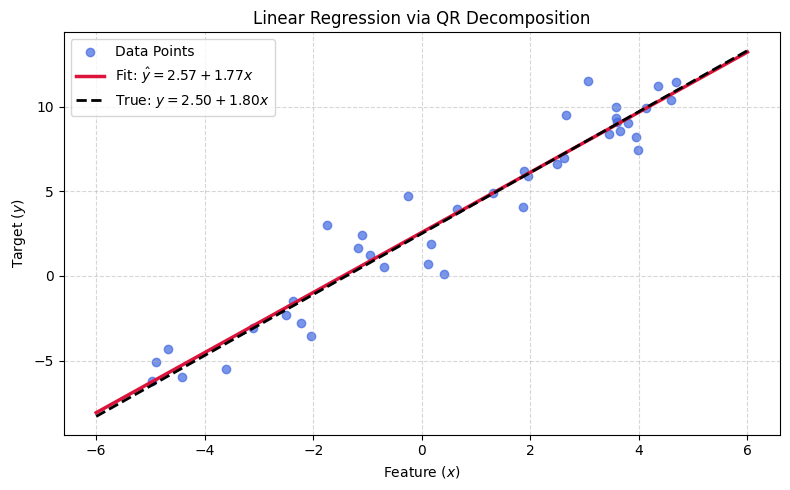

In [ ]:
print("\n--- Linear Regression via QR Decomposition ---")
# 1. Generate random data for example
n_samples = 40
d_features = 1
# Generate random feature values
X = np.random.uniform(
    -5,
    5,
    size=(n_samples, d_features)
)
# True model parameters
true_beta_0 = 2.5
true_beta_1 = 1.8
# Generate random noise
noise = np.random.normal(loc=0,scale=1.5,size=(n_samples, 1))
# Generate target values:  y = beta_0 + beta_1 * x + noise
y = (true_beta_0 + true_beta_1 * X + noise)
# 2. Construct the Matrix
# Add a column of 1s for the intercept
ones_column = np.ones((n_samples, 1))
# Design matrix:
#
# A = [1  X]
A_regression = np.hstack((ones_column, X))
print(
    f"Design Matrix A shape: "
    f"{A_regression.shape}"
)
print(
    f"Target vector y shape: "
    f"{y.shape}"
)
# 3. QR Decomposition
Q_reg, R_reg = qr_decomposition(A_regression)
print(f"Q shape: {Q_reg.shape}")
print(f"R shape: {R_reg.shape}")

# 4. Solve the Least-Squares problem
# Convert y from an n x 1 array to a 1D array
y_flat = y.flatten()
# Compute Q^T y
qty_reg = Q_reg.T @ y_flat
# Solve R beta = Q^T y
beta_hat = back_substitution(
    R_reg,
    qty_reg
)
# 5. Estimated Coefficients
print("\nEstimated Regression Coefficients:")
print(
    f"Beta_0 (Intercept): "
    f"{beta_hat[0]:.4f} "
    f"(True: {true_beta_0})"
)
print(
    f"Beta_1 (Slope):     "
    f"{beta_hat[1]:.4f} "
    f"(True: {true_beta_1})"
)
# 6. Calculate Predictions and Error
# Predicted values
y_hat = A_regression @ beta_hat
# Residuals
residuals = y_flat - y_hat
# Sum of Squared Errors
sse = np.sum(residuals ** 2)
# Mean Squared Error
mse = np.mean(residuals ** 2)
# Root Mean Squared Error
rmse = np.sqrt(mse)
print("\nRegression Error:")
print(f"SSE:  {sse:.4f}")
print(f"MSE:  {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
# 7. Plot the Data and Regression Line
plt.figure(figsize=(8, 5))
# Original data points
plt.scatter(
    X[:, 0],
    y[:, 0],
    color="royalblue",
    alpha=0.7,
    label="Data Points"
)
# Generate x-values for the fitted line
x_line = np.linspace(-6,6,100)
# Predicted y-values
y_line = (beta_hat[0] + beta_hat[1] * x_line)
# Plot fitted regression line
plt.plot(
    x_line,
    y_line,
    color="crimson",
    linewidth=2.5,
    label=(
        f"Fit: $\\hat{{y}} = "
        f"{beta_hat[0]:.2f} + "
        f"{beta_hat[1]:.2f}x$"
    )
)
# Plot the true regression line
y_true_line = (true_beta_0 + true_beta_1 * x_line)
plt.plot(
    x_line,
    y_true_line,
    color="black",
    linestyle="--",
    linewidth=2,
    label=(
        f"True: $y = "
        f"{true_beta_0:.2f} + "
        f"{true_beta_1:.2f}x$"
    )
)
# Labels and formatting
plt.title("Linear Regression via QR Decomposition")
plt.xlabel("Feature ($x$)")
plt.ylabel("Target ($y$)")
plt.grid(True,linestyle="--",alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()